## 1. Import Required Libraries

In [2]:
# !pip install matplotlib searborn

https://clustering-visualizer.web.app/kmeans

In [68]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Date handling
from datetime import datetime

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Data

In [69]:
# Load the dataset
df = pd.read_excel('data/Online Retail.xlsx')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

KeyboardInterrupt: 

## 3. Basic Exploratory Data Analysis (EDA)

### 3.1 First Look at the Data

In [70]:
# Display first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [6]:
# Display last few rows
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.00,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


### 3.2 Dataset Information

In [71]:
# Get dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [72]:
# Check data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)

# Check shape
print(f"\nNumber of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


Number of Rows: 541,909
Number of Columns: 8


### 3.3 Column Names

In [73]:
# Display column names
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Column Names:
1. InvoiceNo
2. StockCode
3. Description
4. Quantity
5. InvoiceDate
6. UnitPrice
7. CustomerID
8. Country


### 3.4 Missing Values Analysis

In [60]:
# Check for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_data)
print("\n" + "="*50)
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")

Missing Values Summary:
                  Column  Missing Count  Missing Percentage
CustomerID    CustomerID         135080               24.93
Description  Description           1454                0.27


Total Missing Values: 136,534


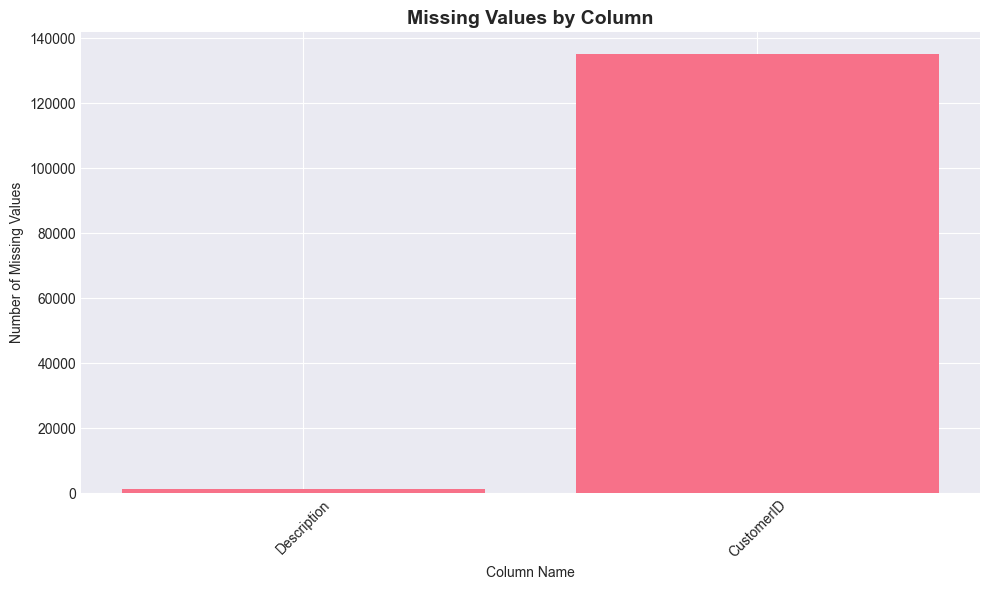

In [74]:
# Visualize missing values
plt.figure(figsize=(10, 6))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

if len(missing_counts) > 0:
    plt.bar(missing_counts.index, missing_counts.values)
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

### 3.5 Statistical Summary

In [77]:
# Statistical summary for numerical columns
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [13]:
# Statistical summary for categorical columns
df.describe(include=['object'])

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


### 3.6 Duplicate Values

In [78]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count:,}")
print(f"Percentage of Duplicates: {(duplicate_count/len(df))*100:.2f}%")

if duplicate_count > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of Duplicate Rows: 5,268
Percentage of Duplicates: 0.97%

Sample of duplicate rows:
    InvoiceNo StockCode                        Description  Quantity  \
485    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
489    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
494    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
521    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
527    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
548    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
555    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   

            InvoiceDate  UnitPrice  CustomerID         Country  
485 2010-12-01 11:45:00       4.95    17908.00  Uni

### 3.7 Unique Values in Categorical Columns

In [79]:
# Check unique values for each column
print("Unique Values Count:")
print("="*50)
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count:,} unique values")

Unique Values Count:
InvoiceNo: 25,900 unique values
StockCode: 4,070 unique values
Description: 4,223 unique values
Quantity: 722 unique values
InvoiceDate: 23,260 unique values
UnitPrice: 1,630 unique values
CustomerID: 4,372 unique values
Country: 38 unique values


### 3.8 Date Range Analysis

In [80]:
# Check date range if InvoiceDate exists
if 'InvoiceDate' in df.columns:
    print("Date Range Analysis:")
    print("="*50)
    print(f"Earliest Date: {df['InvoiceDate'].min()}")
    print(f"Latest Date: {df['InvoiceDate'].max()}")
    print(f"Date Range: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

Date Range Analysis:
Earliest Date: 2010-12-01 08:26:00
Latest Date: 2011-12-09 12:50:00
Date Range: 373 days


### 3.9 Top Products

In [81]:
# Top 10 most sold products
if 'Description' in df.columns:
    print("Top 10 Most Frequently Appearing Products:")
    print("="*50)
    print(df['Description'].value_counts().head(10))

Top 10 Most Frequently Appearing Products:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


### 3.10 Country Distribution

In [82]:
# Country distribution
if 'Country' in df.columns:
    print("Top 10 Countries by Transaction Count:")
    print("="*50)
    print(df['Country'].value_counts().head(10))

Top 10 Countries by Transaction Count:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


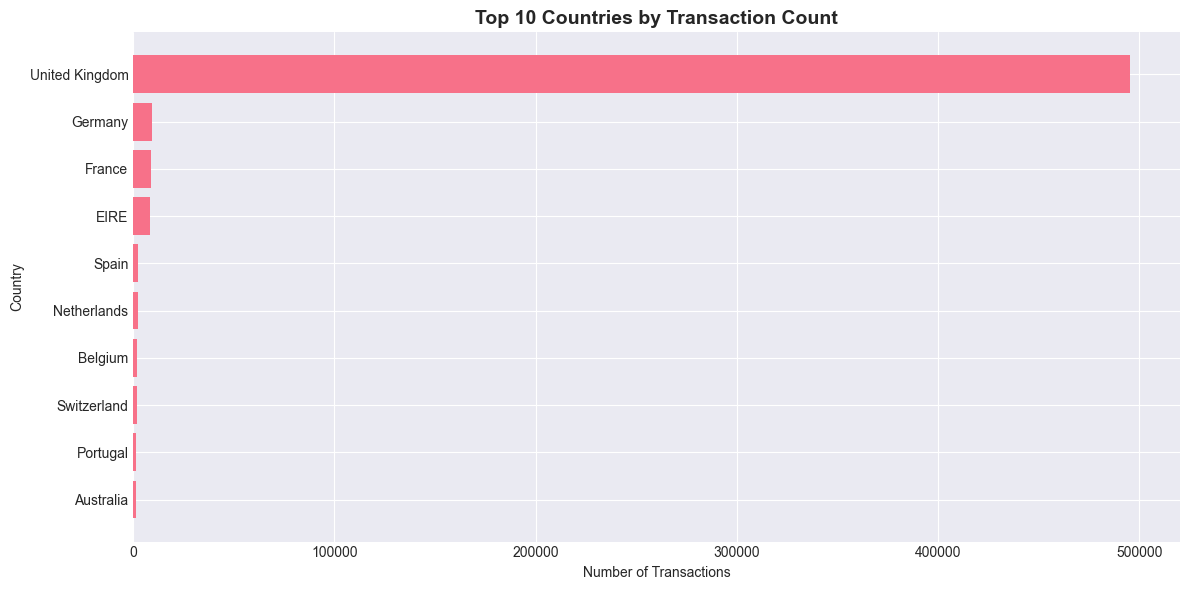

In [83]:
# Visualize top countries
if 'Country' in df.columns:
    plt.figure(figsize=(12, 6))
    top_countries = df['Country'].value_counts().head(10)
    plt.barh(top_countries.index, top_countries.values)
    plt.xlabel('Number of Transactions')
    plt.ylabel('Country')
    plt.title('Top 10 Countries by Transaction Count', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### 3.11 Customer Analysis

In [20]:
# Customer statistics
if 'CustomerID' in df.columns:
    total_customers = df['CustomerID'].nunique()
    print(f"Total Unique Customers: {total_customers:,}")
    
    # Transactions per customer
    transactions_per_customer = df.groupby('CustomerID').size()
    print("\nTransactions per Customer Statistics:")
    print("="*50)
    print(f"Mean: {transactions_per_customer.mean():.2f}")
    print(f"Median: {transactions_per_customer.median():.2f}")
    print(f"Max: {transactions_per_customer.max()}")
    print(f"Min: {transactions_per_customer.min()}")

Total Unique Customers: 4,372

Transactions per Customer Statistics:
Mean: 93.05
Median: 42.00
Max: 7983
Min: 1


### 3.12 Numerical Columns Distribution

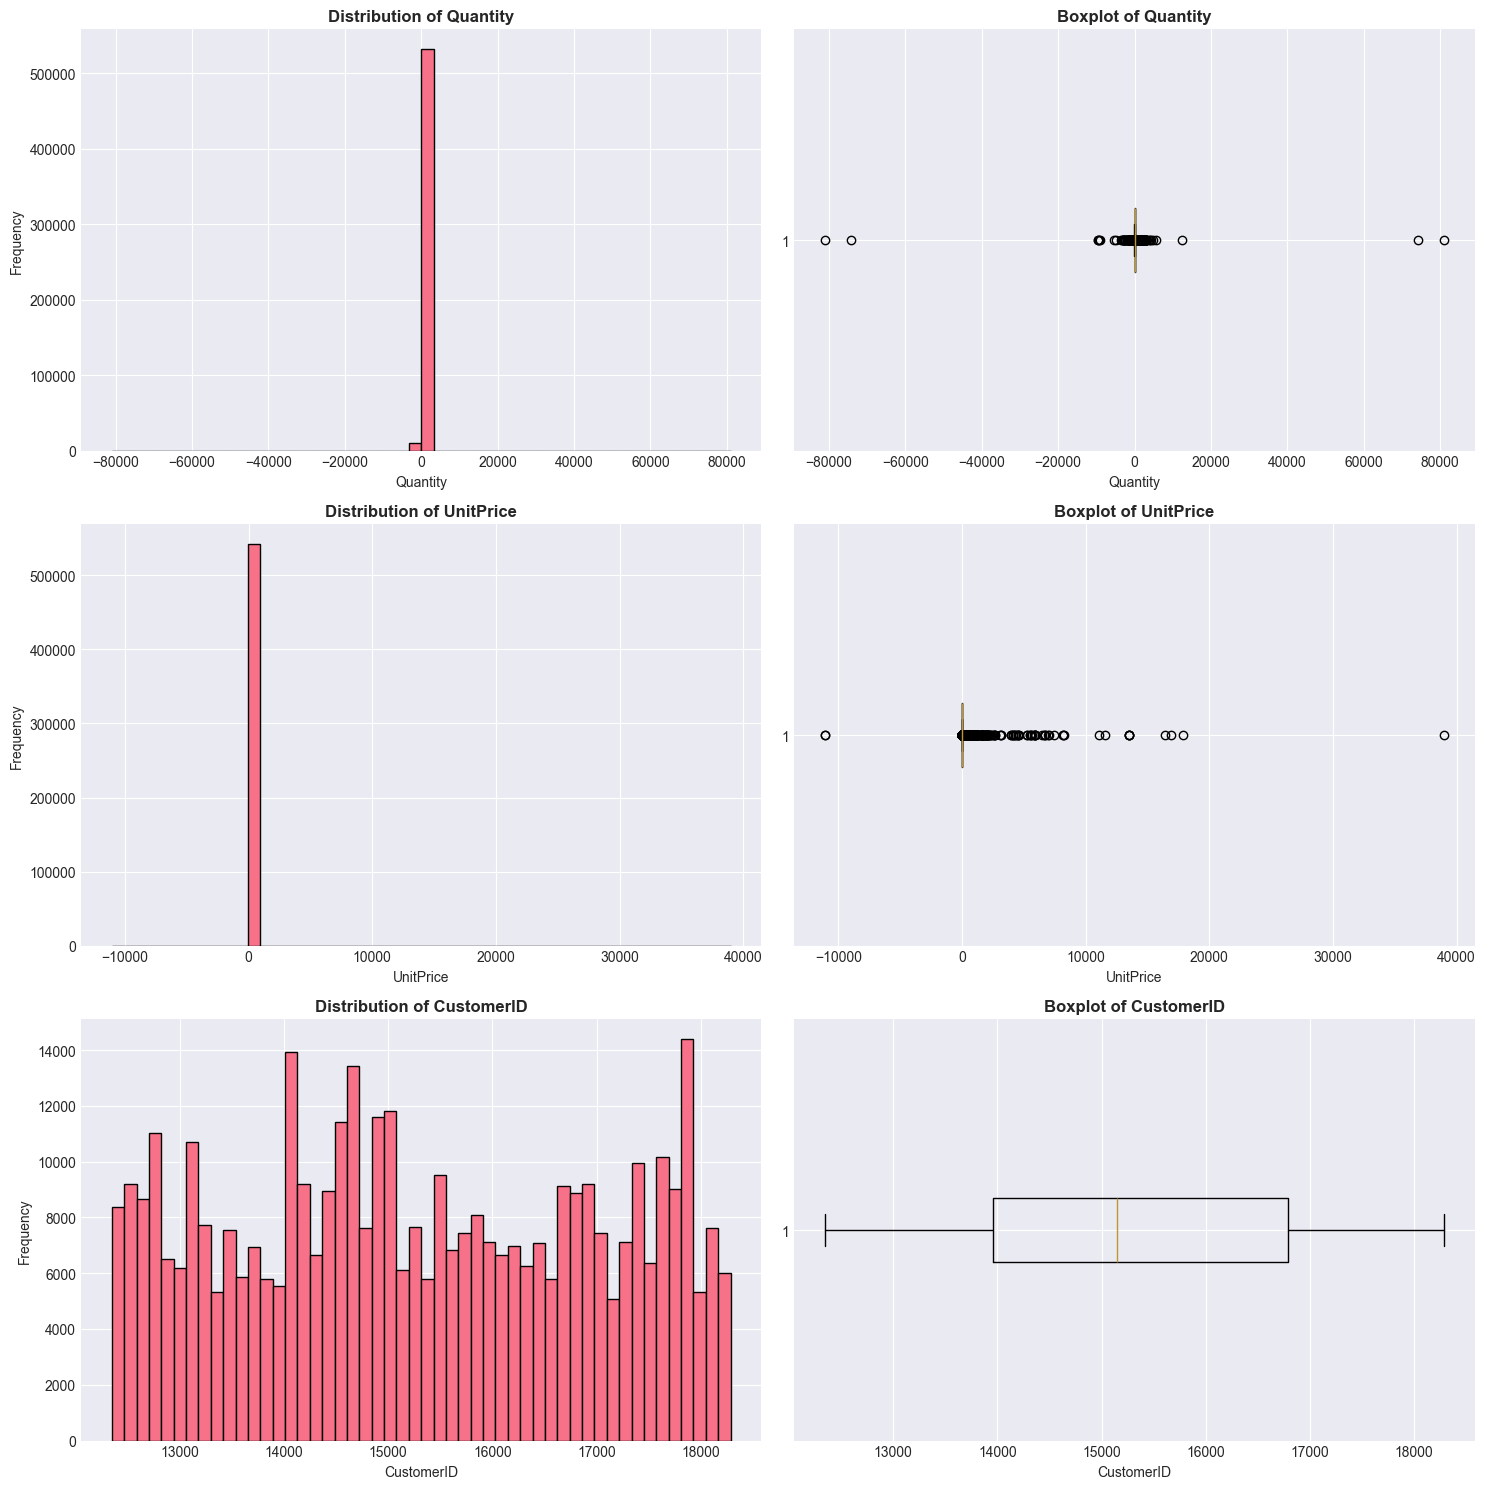

In [21]:
# Visualize numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_cols) > 0:
    fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(15, 5*len(numerical_cols)))
    
    if len(numerical_cols) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(numerical_cols):
        # Histogram
        axes[idx, 0].hist(df[col].dropna(), bins=50, edgecolor='black')
        axes[idx, 0].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx, 0].set_xlabel(col)
        axes[idx, 0].set_ylabel('Frequency')
        
        # Boxplot
        axes[idx, 1].boxplot(df[col].dropna(), vert=False)
        axes[idx, 1].set_title(f'Boxplot of {col}', fontweight='bold')
        axes[idx, 1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

### 3.13 Check for Negative Values

In [84]:
# Check for negative values in Quantity and UnitPrice
if 'Quantity' in df.columns:
    negative_quantity = (df['Quantity'] < 0).sum()
    print(f"Negative Quantity values: {negative_quantity:,} ({(negative_quantity/len(df))*100:.2f}%)")

if 'UnitPrice' in df.columns:
    negative_price = (df['UnitPrice'] < 0).sum()
    zero_price = (df['UnitPrice'] == 0).sum()
    print(f"Negative UnitPrice values: {negative_price:,}")
    print(f"Zero UnitPrice values: {zero_price:,} ({(zero_price/len(df))*100:.2f}%)")

Negative Quantity values: 10,624 (1.96%)
Negative UnitPrice values: 2
Zero UnitPrice values: 2,515 (0.46%)


### 3.14 Invoice Analysis

In [23]:
# Analyze invoices
if 'InvoiceNo' in df.columns:
    total_invoices = df['InvoiceNo'].nunique()
    print(f"Total Unique Invoices: {total_invoices:,}")
    
    # Check for cancelled orders (InvoiceNo starting with 'C')
    cancelled = df['InvoiceNo'].astype(str).str.startswith('C').sum()
    print(f"\nCancelled Orders (starting with 'C'): {cancelled:,} ({(cancelled/len(df))*100:.2f}%)")

Total Unique Invoices: 25,900

Cancelled Orders (starting with 'C'): 9,288 (1.71%)


### 3.15 Data Quality Summary

In [24]:
# Comprehensive data quality summary
print("DATA QUALITY SUMMARY")
print("="*70)
print(f"\n1. Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n2. Missing Values: {df.isnull().sum().sum():,} ({(df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100:.2f}%)")
print(f"\n3. Duplicate Rows: {df.duplicated().sum():,}")
print(f"\n4. Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'CustomerID' in df.columns:
    print(f"\n5. Unique Customers: {df['CustomerID'].nunique():,}")
    print(f"   - Missing CustomerIDs: {df['CustomerID'].isnull().sum():,}")

if 'InvoiceNo' in df.columns:
    print(f"\n6. Unique Invoices: {df['InvoiceNo'].nunique():,}")

if 'Country' in df.columns:
    print(f"\n7. Countries: {df['Country'].nunique()}")

print("\n" + "="*70)

DATA QUALITY SUMMARY

1. Dataset Shape: 541,909 rows × 8 columns

2. Missing Values: 136,534 (3.15%)

3. Duplicate Rows: 5,268

4. Memory Usage: 126.18 MB

5. Unique Customers: 4,372
   - Missing CustomerIDs: 135,080

6. Unique Invoices: 25,900

7. Countries: 38



## Summary of Basic EDA

Based on the exploratory analysis above:
- We have identified the structure and quality of our data
- We understand the distribution of transactions across customers and countries
- We've identified missing values and potential data quality issues
- We've examined numerical distributions and outliers

Next steps will involve:
1. Data cleaning and preprocessing
2. Creating RFM features
3. Feature scaling
4. Finding optimal number of clusters
5. Performing customer segmentation

## 4. Data Cleaning and Preprocessing

Now we'll clean the data to prepare it for RFM analysis and clustering.

### 4.1 Create a Copy of Original Data

In [25]:
# Create a copy to preserve original data
df_clean = df.copy()

print(f"Original shape: {df_clean.shape}")
print(f"Original records: {len(df_clean):,}")

Original shape: (541909, 8)
Original records: 541,909


### 4.2 Remove Missing CustomerIDs

CustomerID is essential for customer segmentation, so we'll remove rows without it.

In [26]:
# Remove rows with missing CustomerID
before = len(df_clean)
df_clean = df_clean[df_clean['CustomerID'].notna()]
after = len(df_clean)

print(f"Removed {before - after:,} rows with missing CustomerID")
print(f"Remaining records: {after:,}")

Removed 135,080 rows with missing CustomerID
Remaining records: 406,829


### 4.3 Remove Cancelled Orders

Orders with InvoiceNo starting with 'C' are cancellations/returns.

In [27]:
# Remove cancelled orders (InvoiceNo starting with 'C')
before = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
after = len(df_clean)

print(f"Removed {before - after:,} cancelled orders")
print(f"Remaining records: {after:,}")

Removed 8,905 cancelled orders
Remaining records: 397,924


### 4.4 Remove Negative and Zero Values

Remove records with negative or zero Quantity and UnitPrice.

In [28]:
# Remove negative and zero values
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
after = len(df_clean)

print(f"Removed {before - after:,} rows with negative or zero Quantity/UnitPrice")
print(f"Remaining records: {after:,}")

Removed 40 rows with negative or zero Quantity/UnitPrice
Remaining records: 397,884


### 4.5 Create Total Amount Column

In [29]:
# Create TotalAmount column
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("TotalAmount column created successfully!")
print(f"\nSample data:")
print(df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head())

TotalAmount column created successfully!

Sample data:
   Quantity  UnitPrice  TotalAmount
0         6       2.55        15.30
1         6       3.39        20.34
2         8       2.75        22.00
3         6       3.39        20.34
4         6       3.39        20.34


### 4.6 Final Clean Data Summary

In [30]:
# Summary of cleaned data
print("CLEANED DATA SUMMARY")
print("="*70)
print(f"Final shape: {df_clean.shape}")
print(f"Total records: {len(df_clean):,}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Total revenue: ${df_clean['TotalAmount'].sum():,.2f}")
print("="*70)

CLEANED DATA SUMMARY
Final shape: (397884, 9)
Total records: 397,884
Unique customers: 4,338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total revenue: $8,911,407.90


## 5. RFM Analysis

**RFM Analysis** is a customer segmentation technique based on three key metrics:

- **Recency (R)**: How recently a customer made a purchase (days since last purchase)
- **Frequency (F)**: How often a customer makes purchases (number of transactions)
- **Monetary (M)**: How much money a customer spends (total amount spent)

### Why RFM is Important:
- **Recency**: Recent customers are more likely to respond to promotions
- **Frequency**: Frequent customers show loyalty and engagement
- **Monetary**: High-spending customers contribute most to revenue

### 5.1 Calculate Reference Date

In [31]:
# Calculate reference date (1 day after the last transaction)
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency Calculation: {reference_date}")

Reference Date for Recency Calculation: 2011-12-10 12:50:00


In [85]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34


### 5.2 Calculate RFM Metrics

In [87]:
# Calculate RFM metrics for each customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency (unique invoices)
    'TotalAmount': 'mean'  # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Data Created Successfully!")
print(f"\nShape: {rfm.shape}")
print(f"\nFirst 10 customers:")
rfm.head(10)

RFM Data Created Successfully!

Shape: (4338, 4)

First 10 customers:


,CustomerID,Recency,Frequency,Monetary
0,12346.00,326,1,77183.60
1,12347.00,2,7,23.68
2,12348.00,75,4,57.98
3,12349.00,19,1,24.08
4,12350.00,310,1,19.67
5,12352.00,36,8,29.48
6,12353.00,204,1,22.25
7,12354.00,232,1,18.61
8,12355.00,214,1,35.34
9,12356.00,23,3,47.65


### 5.3 RFM Statistical Summary

In [33]:
# Statistical summary of RFM
print("RFM STATISTICAL SUMMARY")
print("="*70)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print("\n" + "="*70)
print("INTERPRETATION:")
print("- Recency: Lower is better (recent customers)")
print("- Frequency: Higher is better (loyal customers)")
print("- Monetary: Higher is better (high-value customers)")

RFM STATISTICAL SUMMARY
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     92.54       4.27   2054.27
std     100.01       7.70   8989.23
min       1.00       1.00      3.75
25%      18.00       1.00    307.41
50%      51.00       2.00    674.49
75%     142.00       5.00   1661.74
max     374.00     209.00 280206.02

INTERPRETATION:
- Recency: Lower is better (recent customers)
- Frequency: Higher is better (loyal customers)
- Monetary: Higher is better (high-value customers)


### 5.4 RFM Distribution Visualization

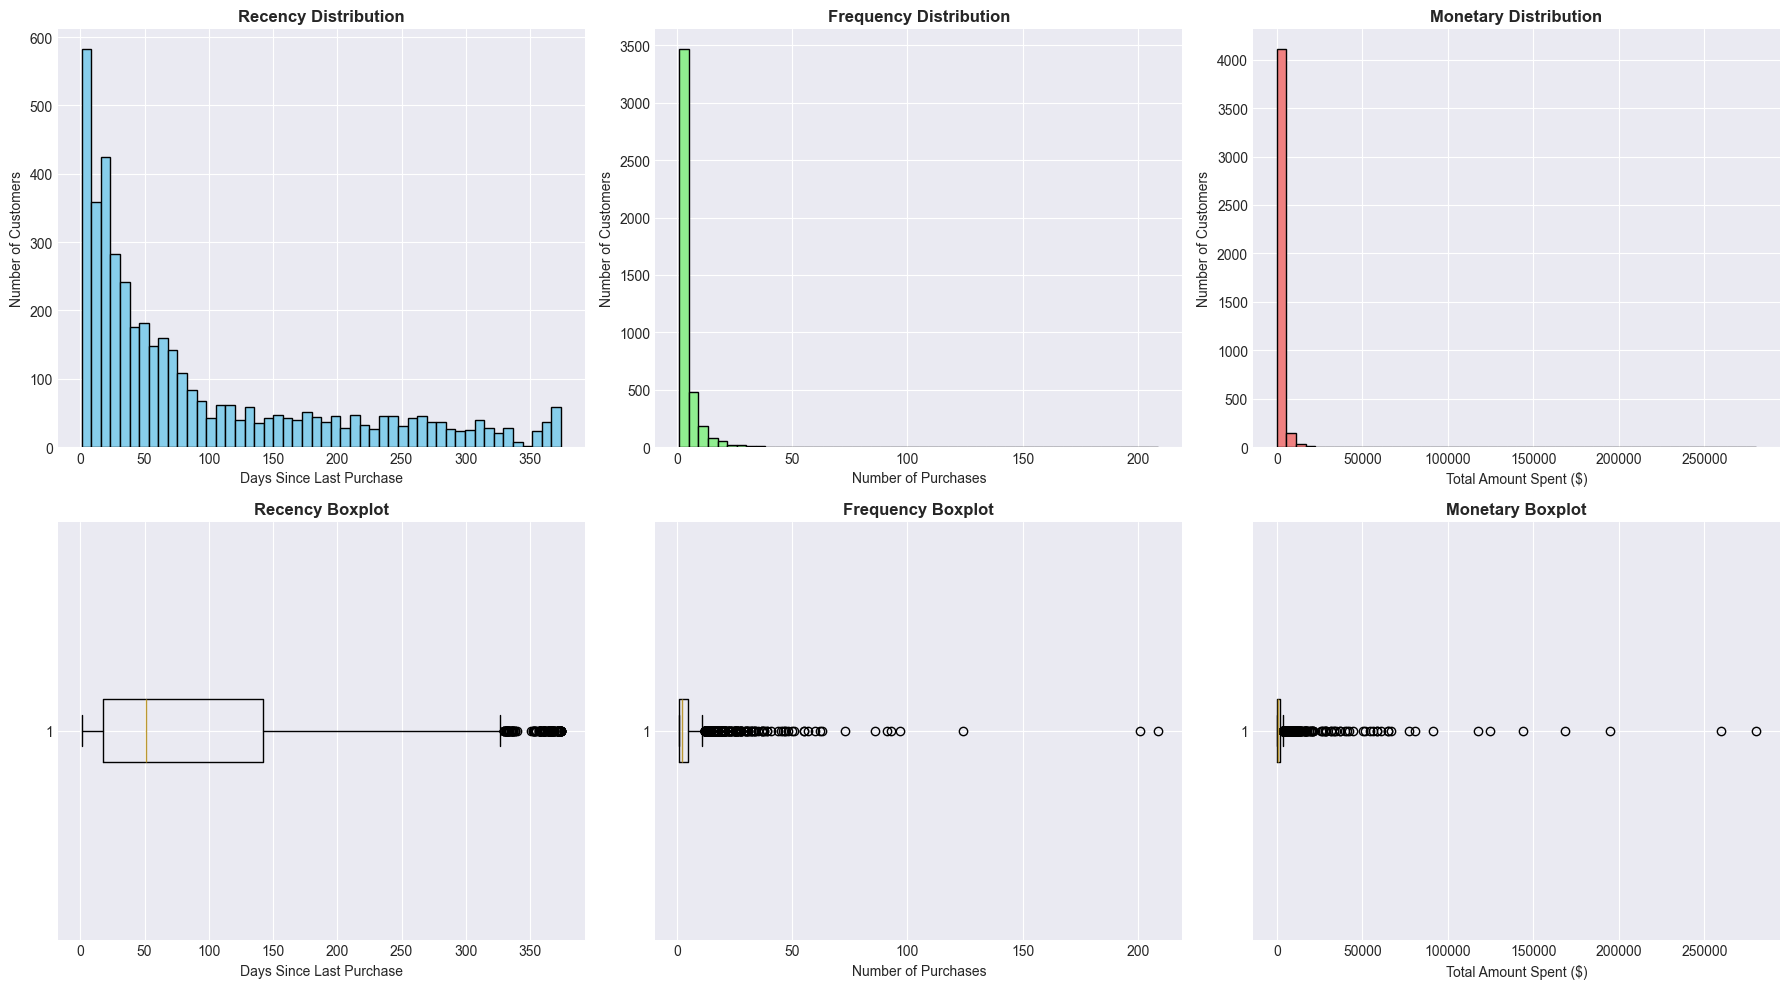

✓ RFM distributions show the spread of customer behavior


In [34]:
# Visualize RFM distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Recency
axes[0, 0].hist(rfm['Recency'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Recency Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Days Since Last Purchase')
axes[0, 0].set_ylabel('Number of Customers')

axes[1, 0].boxplot(rfm['Recency'], vert=False)
axes[1, 0].set_title('Recency Boxplot', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Days Since Last Purchase')

# Frequency
axes[0, 1].hist(rfm['Frequency'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Frequency Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Purchases')
axes[0, 1].set_ylabel('Number of Customers')

axes[1, 1].boxplot(rfm['Frequency'], vert=False)
axes[1, 1].set_title('Frequency Boxplot', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Purchases')

# Monetary
axes[0, 2].hist(rfm['Monetary'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 2].set_title('Monetary Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Total Amount Spent ($)')
axes[0, 2].set_ylabel('Number of Customers')

axes[1, 2].boxplot(rfm['Monetary'], vert=False)
axes[1, 2].set_title('Monetary Boxplot', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Total Amount Spent ($)')

plt.tight_layout()
plt.show()

print("✓ RFM distributions show the spread of customer behavior")

## 6. Feature Scaling

**Feature Scaling** is crucial before applying clustering algorithms because:
- Features with larger ranges can dominate the distance calculations
- K-Means uses Euclidean distance, which is sensitive to feature magnitude
- Scaling ensures all features contribute equally to the clustering

### Types of Scalers:

#### 1. **StandardScaler (Z-score Normalization)**
- Formula: `(x - mean) / std_deviation`
- Centers data around mean = 0, std = 1
- **When to use**: When data follows normal distribution
- **Effect**: Sensitive to outliers

#### 2. **MinMaxScaler**
- Formula: `(x - min) / (max - min)`
- Scales data to range [0, 1]
- **When to use**: When you need bounded values
- **Effect**: Very sensitive to outliers

#### 3. **RobustScaler**
- Formula: `(x - median) / IQR`
- Uses median and Inter-Quartile Range (IQR)
- **When to use**: When data has many outliers
- **Effect**: Robust to outliers

### 6.1 Prepare Data for Scaling

In [35]:
# Prepare features for scaling
X = rfm[['Recency', 'Frequency', 'Monetary']].values

print(f"Feature matrix shape: {X.shape}")
print(f"\nOriginal data (first 5 customers):")
print(rfm[['Recency', 'Frequency', 'Monetary']].head())

Feature matrix shape: (4338, 3)

Original data (first 5 customers):
   Recency  Frequency  Monetary
0      326          1  77183.60
1        2          7   4310.00
2       75          4   1797.24
3       19          1   1757.55
4      310          1    334.40


### 6.2 Apply Different Scalers

In [36]:
# Apply StandardScaler
standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X)

# Apply MinMaxScaler
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

# Apply RobustScaler
robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X)

print("✓ All three scalers applied successfully!")
print(f"\nScaled data shapes:")
print(f"  StandardScaler: {X_standard.shape}")
print(f"  MinMaxScaler: {X_minmax.shape}")
print(f"  RobustScaler: {X_robust.shape}")

✓ All three scalers applied successfully!

Scaled data shapes:
  StandardScaler: (4338, 3)
  MinMaxScaler: (4338, 3)
  RobustScaler: (4338, 3)


### 6.3 Compare Scaled Data

In [37]:
# Compare first 5 customers across different scalers
comparison_df = pd.DataFrame({
    'Customer': range(1, 6),
    'Original_R': X[:5, 0],
    'Standard_R': X_standard[:5, 0],
    'MinMax_R': X_minmax[:5, 0],
    'Robust_R': X_robust[:5, 0],
})

print("COMPARISON OF RECENCY VALUES (First 5 Customers)")
print("="*70)
print(comparison_df)

print("\n\nKEY OBSERVATIONS:")
print("-" * 70)
print("StandardScaler: Centers around 0, can have negative values")
print("MinMaxScaler: All values between 0 and 1")
print("RobustScaler: Values can be outside [0,1], less affected by outliers")

COMPARISON OF RECENCY VALUES (First 5 Customers)
   Customer  Original_R  Standard_R  MinMax_R  Robust_R
0         1      326.00        2.33      0.87      2.22
1         2        2.00       -0.91      0.00     -0.40
2         3       75.00       -0.18      0.20      0.19
3         4       19.00       -0.74      0.05     -0.26
4         5      310.00        2.17      0.83      2.09


KEY OBSERVATIONS:
----------------------------------------------------------------------
StandardScaler: Centers around 0, can have negative values
MinMaxScaler: All values between 0 and 1
RobustScaler: Values can be outside [0,1], less affected by outliers


### 6.4 Visualize Scaling Effects

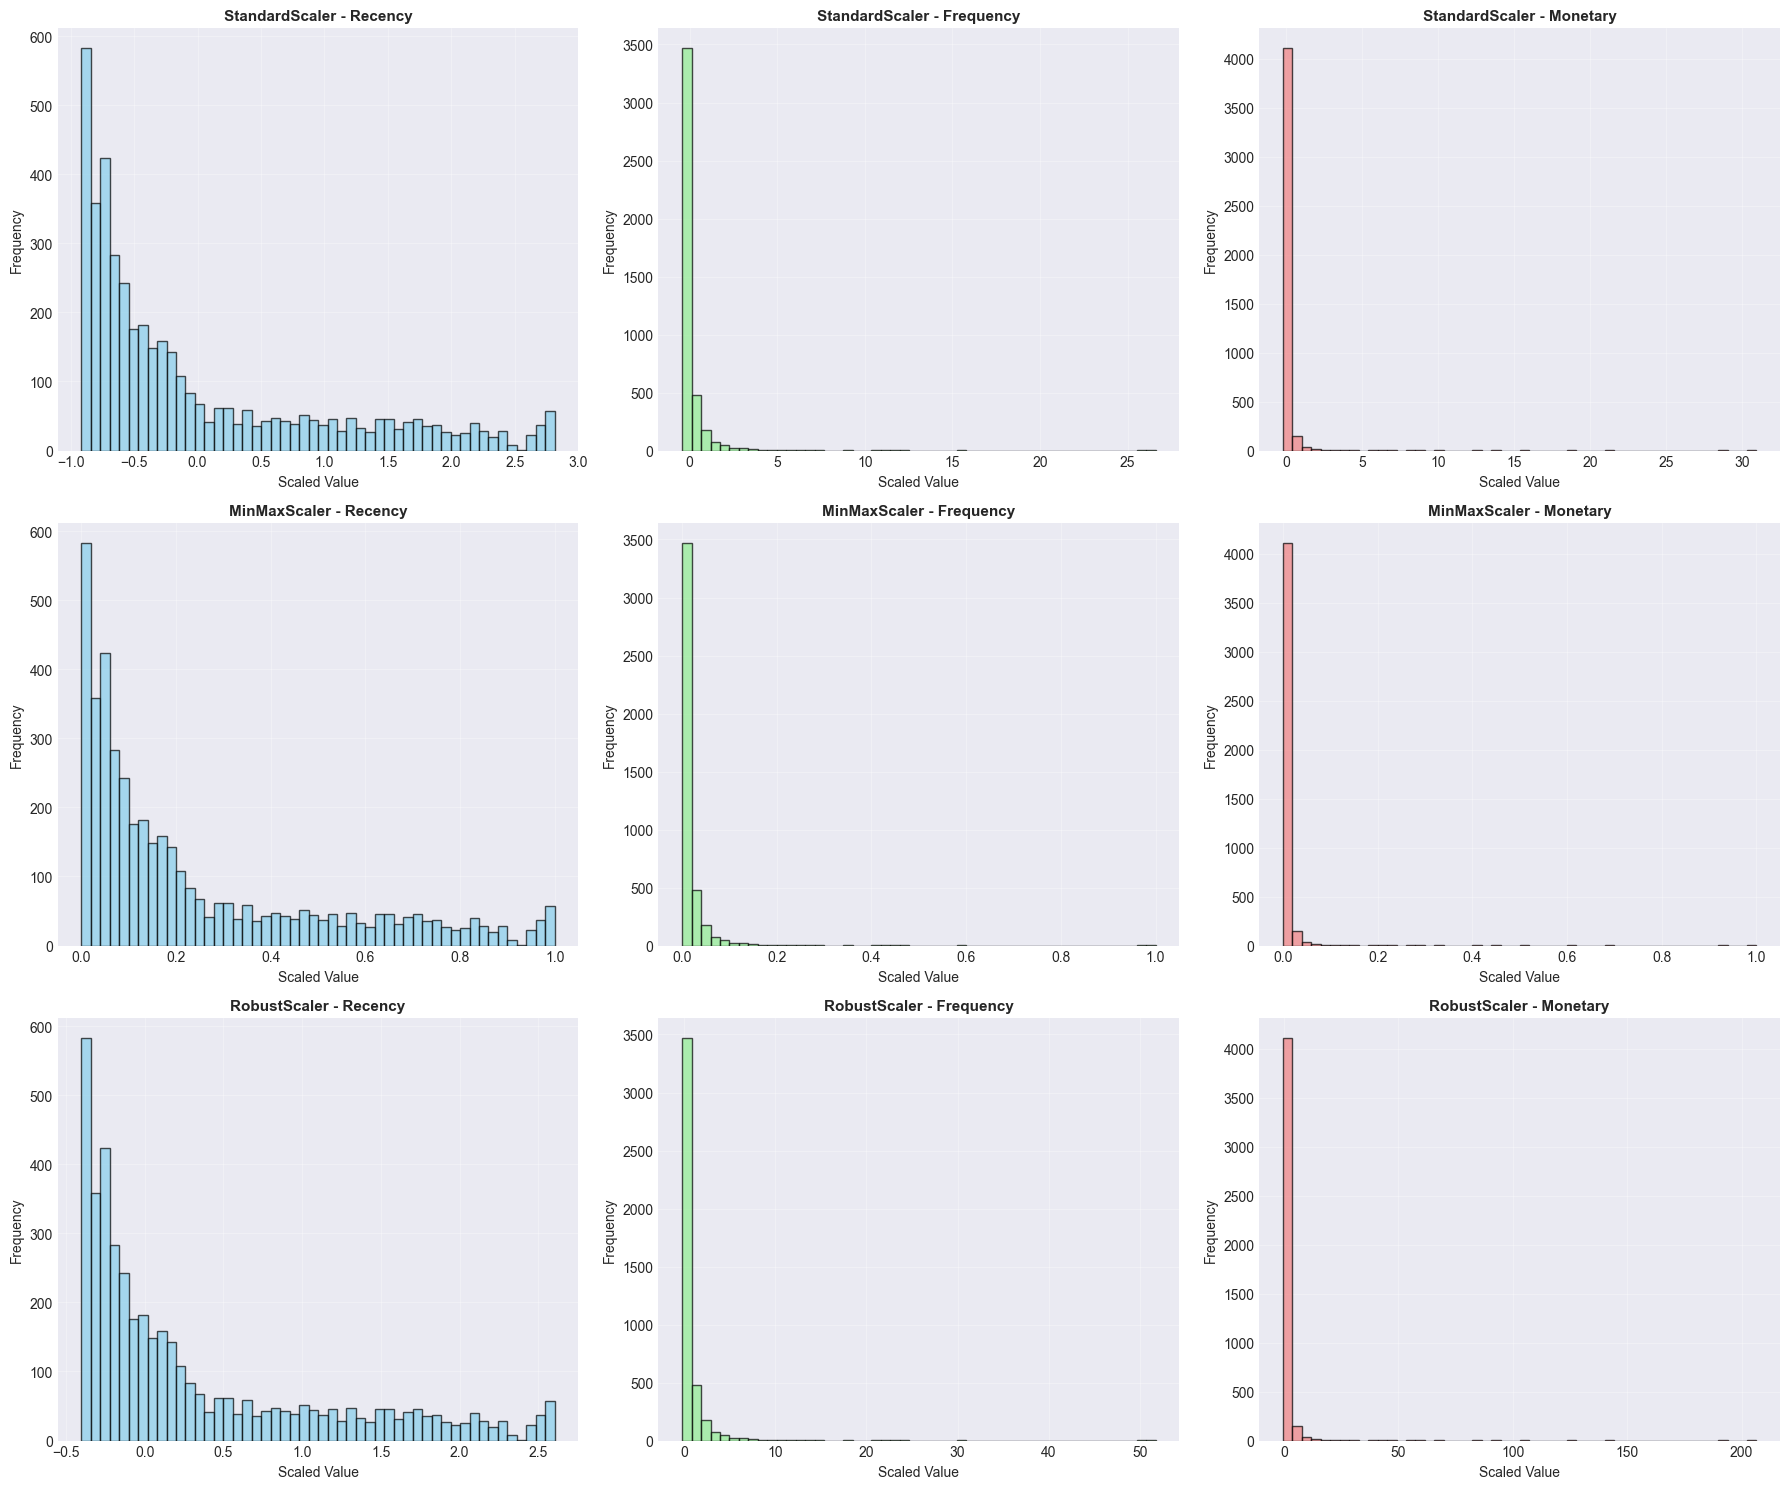

✓ Visualization shows how different scalers transform the data


In [38]:
# Visualize the effect of different scalers
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

features = ['Recency', 'Frequency', 'Monetary']
scaled_data = [X_standard, X_minmax, X_robust]
scaler_names = ['StandardScaler', 'MinMaxScaler', 'RobustScaler']

for i, scaler_name in enumerate(scaler_names):
    for j, feature in enumerate(features):
        axes[i, j].hist(scaled_data[i][:, j], bins=50, color=['skyblue', 'lightgreen', 'lightcoral'][j], 
                       edgecolor='black', alpha=0.7)
        axes[i, j].set_title(f'{scaler_name} - {feature}', fontsize=11, fontweight='bold')
        axes[i, j].set_xlabel('Scaled Value')
        axes[i, j].set_ylabel('Frequency')
        axes[i, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization shows how different scalers transform the data")

### 6.5 Select Scaler for Clustering

For this project, we'll use **StandardScaler** because:
- It's the most commonly used scaler for K-Means
- Works well when features have different units
- Our RFM data benefits from standardization

In [39]:
# Use StandardScaler for clustering
X_scaled = X_standard.copy()
print("✓ StandardScaler selected for clustering")
print(f"Scaled data shape: {X_scaled.shape}")

✓ StandardScaler selected for clustering
Scaled data shape: (4338, 3)


## 7. Finding Optimal Number of Clusters

Before applying K-Means, we need to determine the optimal number of clusters. We'll use three methods:

### 7.1 Elbow Method (WSS - Within-Cluster Sum of Squares)

**What is WSS?**
- WSS measures the compactness of clusters
- It's the sum of squared distances between points and their cluster centroid
- Formula: $WSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$

**Elbow Method:**
- Plot WSS for different values of k
- Look for the "elbow" point where WSS starts decreasing slowly
- The elbow represents the optimal trade-off between cluster count and compactness

**Impact:**
- Lower WSS = more compact clusters
- But too many clusters lead to overfitting

In [40]:
# Calculate WSS for different numbers of clusters
wss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)  # inertia_ is the WSS
    print(f"k={k}: WSS = {kmeans.inertia_:.2f}")

print("\n✓ WSS calculated for k = 2 to 10")

k=2: WSS = 9012.64
k=3: WSS = 5439.30
k=4: WSS = 4092.14
k=5: WSS = 3118.28
k=6: WSS = 2472.57
k=7: WSS = 2022.41
k=8: WSS = 1742.37
k=9: WSS = 1445.63
k=10: WSS = 1303.39

✓ WSS calculated for k = 2 to 10


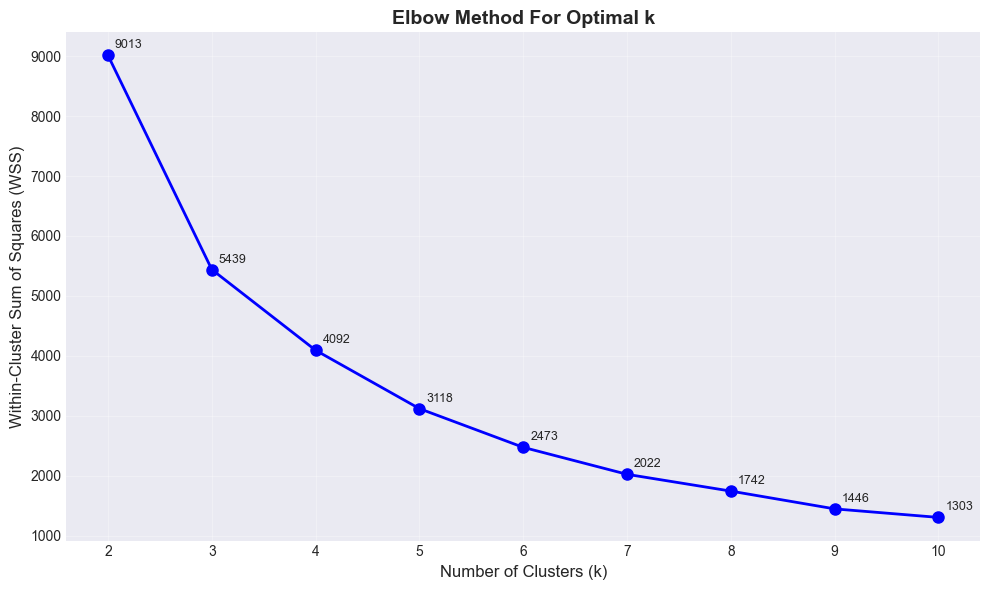


INTERPRETATION:
- Look for the 'elbow' where the curve bends
- After the elbow, adding more clusters doesn't significantly reduce WSS
- The elbow point suggests the optimal number of clusters


In [41]:
# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, wss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WSS)', fontsize=12)
plt.title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Mark potential elbow points
for i, (k, w) in enumerate(zip(k_range, wss)):
    plt.annotate(f'{w:.0f}', xy=(k, w), xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("- Look for the 'elbow' where the curve bends")
print("- After the elbow, adding more clusters doesn't significantly reduce WSS")
print("- The elbow point suggests the optimal number of clusters")

### 7.2 Silhouette Score Method

**What is Silhouette Score?**
- Measures how similar a point is to its own cluster compared to other clusters
- Range: -1 to +1
  - **+1**: Point is well-matched to its cluster and far from others
  - **0**: Point is on the boundary between clusters
  - **-1**: Point might be assigned to the wrong cluster

**Formula:**
$$s(i) = \frac{b(i) - a(i)}{max(a(i), b(i))}$$

Where:
- $a(i)$ = average distance to points in same cluster
- $b(i)$ = average distance to points in nearest cluster

**Impact:**
- Higher score = better-defined clusters
- Helps identify the number of clusters that maximize separation

In [42]:
# Calculate Silhouette Score for different numbers of clusters
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

print("\n✓ Silhouette scores calculated for k = 2 to 10")

k=2: Silhouette Score = 0.8958
k=3: Silhouette Score = 0.5942
k=4: Silhouette Score = 0.6162
k=5: Silhouette Score = 0.6165
k=6: Silhouette Score = 0.5963
k=7: Silhouette Score = 0.5165
k=8: Silhouette Score = 0.5175
k=9: Silhouette Score = 0.4777
k=10: Silhouette Score = 0.4271

✓ Silhouette scores calculated for k = 2 to 10


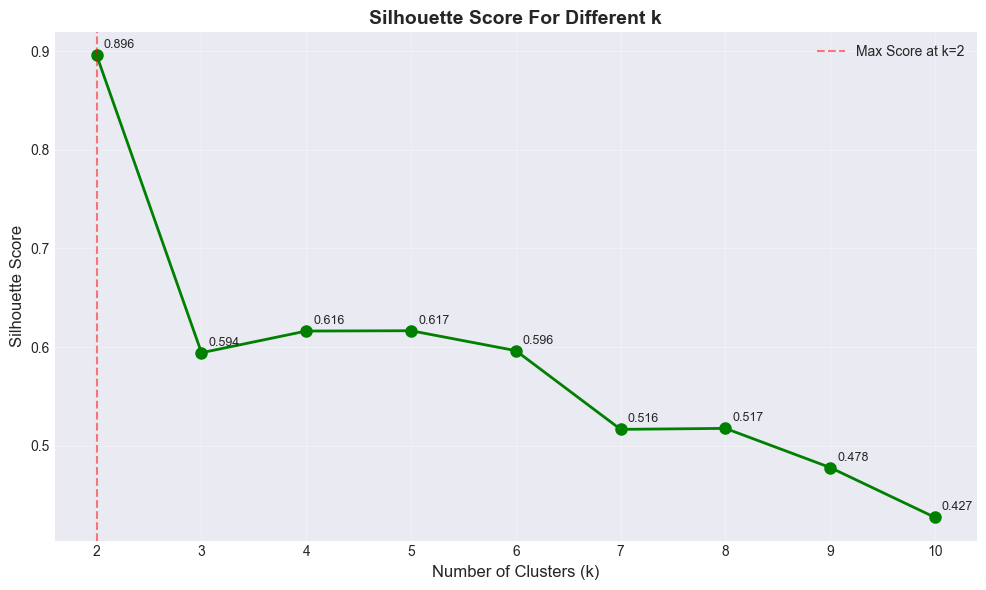


INTERPRETATION:
- Highest Silhouette Score: 0.8958 at k=2
- Higher score indicates better-defined clusters
- Choose k with the highest silhouette score


In [43]:
# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score For Different k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Mark scores
for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    plt.annotate(f'{score:.3f}', xy=(k, score), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Highlight maximum
max_score_idx = silhouette_scores.index(max(silhouette_scores))
max_k = list(k_range)[max_score_idx]
plt.axvline(x=max_k, color='r', linestyle='--', alpha=0.5, label=f'Max Score at k={max_k}')
plt.legend()

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print(f"- Highest Silhouette Score: {max(silhouette_scores):.4f} at k={max_k}")
print("- Higher score indicates better-defined clusters")
print("- Choose k with the highest silhouette score")

### 7.3 Combined Analysis: Elbow + Silhouette

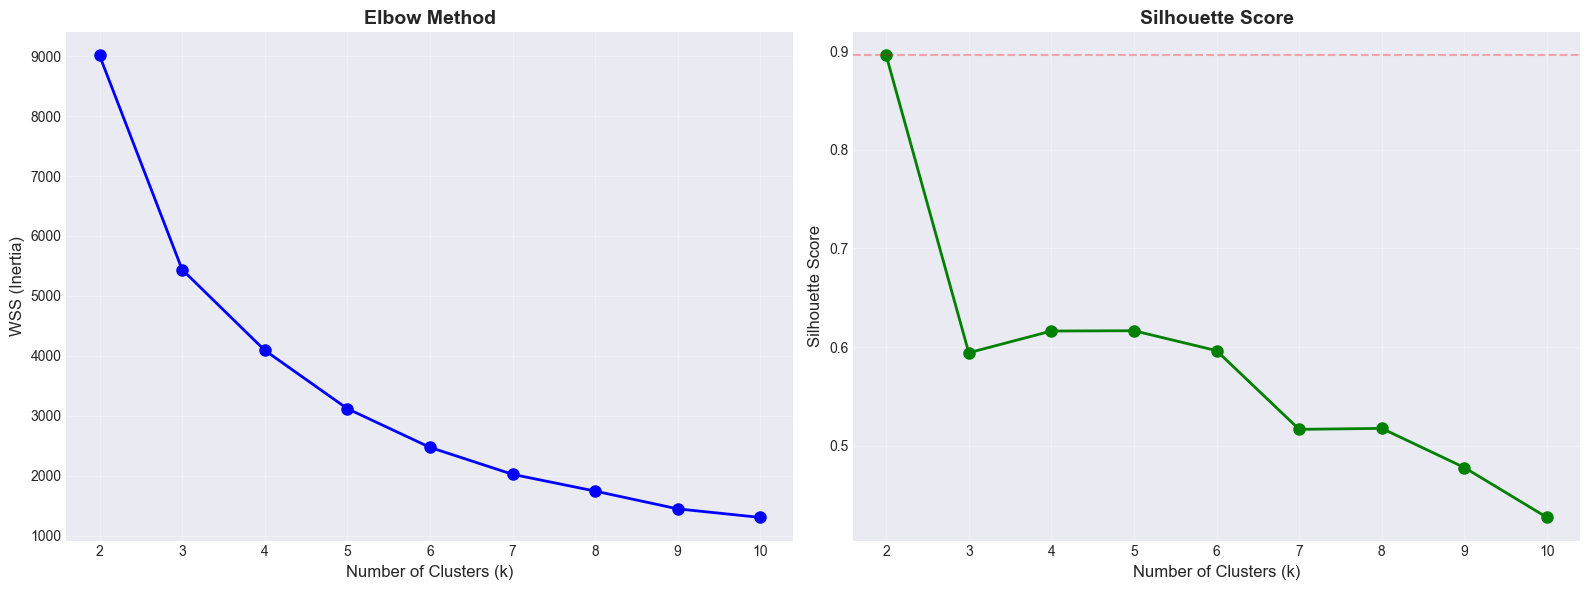


COMBINED ANALYSIS:
1. Elbow Method suggests looking for the bend in WSS curve
2. Silhouette Score is maximized at k=2 (Score: 0.8958)

✓ Based on both methods, optimal k appears to be around 2


In [44]:
# Plot both metrics together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot
ax1.plot(k_range, wss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('WSS (Inertia)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
ax2.axhline(y=max(silhouette_scores), color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCOMBINED ANALYSIS:")
print("="*70)
print(f"1. Elbow Method suggests looking for the bend in WSS curve")
print(f"2. Silhouette Score is maximized at k={max_k} (Score: {max(silhouette_scores):.4f})")
print(f"\n✓ Based on both methods, optimal k appears to be around {max_k}")

### 7.4 Silhouette Plot for Visual Analysis

Silhouette plots show the silhouette coefficient for each sample, grouped by cluster. This helps visualize:
- How well each cluster is separated
- If any clusters have many poorly-assigned samples
- Whether cluster sizes are balanced

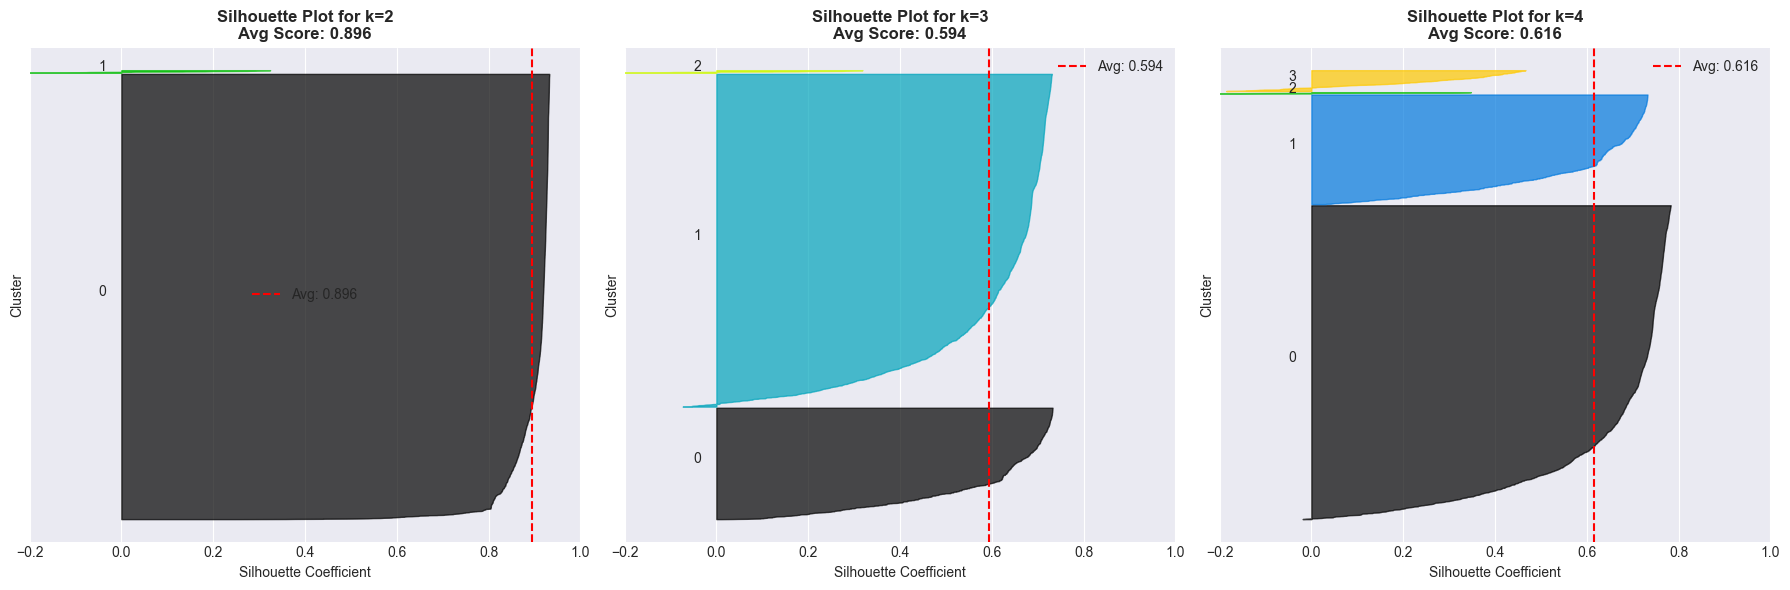


INTERPRETATION:
- Wider silhouettes = better-separated clusters
- All samples should be above the average line (red dashed)
- Similar widths across clusters = balanced cluster sizes


In [67]:
# Create silhouette plots for k=3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, k in enumerate([2,3, 4]):
    ax = axes[idx]
    
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate silhouette scores for each sample
    silhouette_vals = silhouette_samples(X_scaled, labels)
    avg_score = silhouette_score(X_scaled, labels)
    
    y_lower = 10
    for i in range(k):
        # Get silhouette scores for cluster i
        cluster_silhouette_vals = silhouette_vals[labels == i]
        cluster_silhouette_vals.sort()
        
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = plt.cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax.set_title(f'Silhouette Plot for k={k}\nAvg Score: {avg_score:.3f}', fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg: {avg_score:.3f}')
    ax.set_yticks([])
    ax.set_xlim([-0.2, 1])
    ax.legend()

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("- Wider silhouettes = better-separated clusters")
print("- All samples should be above the average line (red dashed)")
print("- Similar widths across clusters = balanced cluster sizes")

## 8. K-Means Clustering

Now we'll apply K-Means clustering with the optimal number of clusters determined above.

### 8.1 Select Optimal K

In [88]:
# Select optimal number of clusters (we'll use 4 as an example, adjust based on your analysis)
optimal_k = 2
print(f"Selected optimal number of clusters: {optimal_k}")

Selected optimal number of clusters: 2


### 8.2 Fit K-Means Model

In [89]:
# Fit final K-Means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = final_kmeans.fit_predict(X_scaled)

# Calculate final metrics
final_wss = final_kmeans.inertia_
final_silhouette = silhouette_score(X_scaled, rfm['Cluster'])

print("✓ K-Means model trained successfully!")
print(f"\nModel Metrics:")
print(f"  Number of clusters: {optimal_k}")
print(f"  WSS (Inertia): {final_wss:.2f}")
print(f"  Silhouette Score: {final_silhouette:.4f}")
print(f"\nCluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())

✓ K-Means model trained successfully!

Model Metrics:
  Number of clusters: 2
  WSS (Inertia): 9012.64
  Silhouette Score: 0.8958

Cluster distribution:
Cluster
0    4312
1      26
Name: count, dtype: int64


### 8.3 Cluster Analysis and Profiling

In [91]:
# Analyze cluster characteristics
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std', 'min', 'max'])

print("CLUSTER PROFILE ANALYSIS")
print("="*100)
print(cluster_profile)

print("\n" + "="*100)
print("\nCLUSTER SUMMARY:")
print("-"*100)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)
cluster_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
print(cluster_summary)

CLUSTER PROFILE ANALYSIS
        Recency                        Frequency                        \
           mean median    std min  max      mean median   std min  max   
Cluster                                                                  
0         93.06  51.00 100.09   1  374      3.90   2.00  4.71   1   55   
1          6.04   3.50   8.60   1   39     66.42  53.00 49.13   2  209   

        Monetary                                
            mean median      std  min      max  
Cluster                                         
0          54.70  17.71  1198.96 2.10 77183.60  
1        2331.81 100.51 10980.42 4.50 56157.50  


CLUSTER SUMMARY:
----------------------------------------------------------------------------------------------------
         Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count
Cluster                                                          
0              93.06           3.90         54.70            4312
1               6.04          66.42      

### 8.4 Visualize Clusters

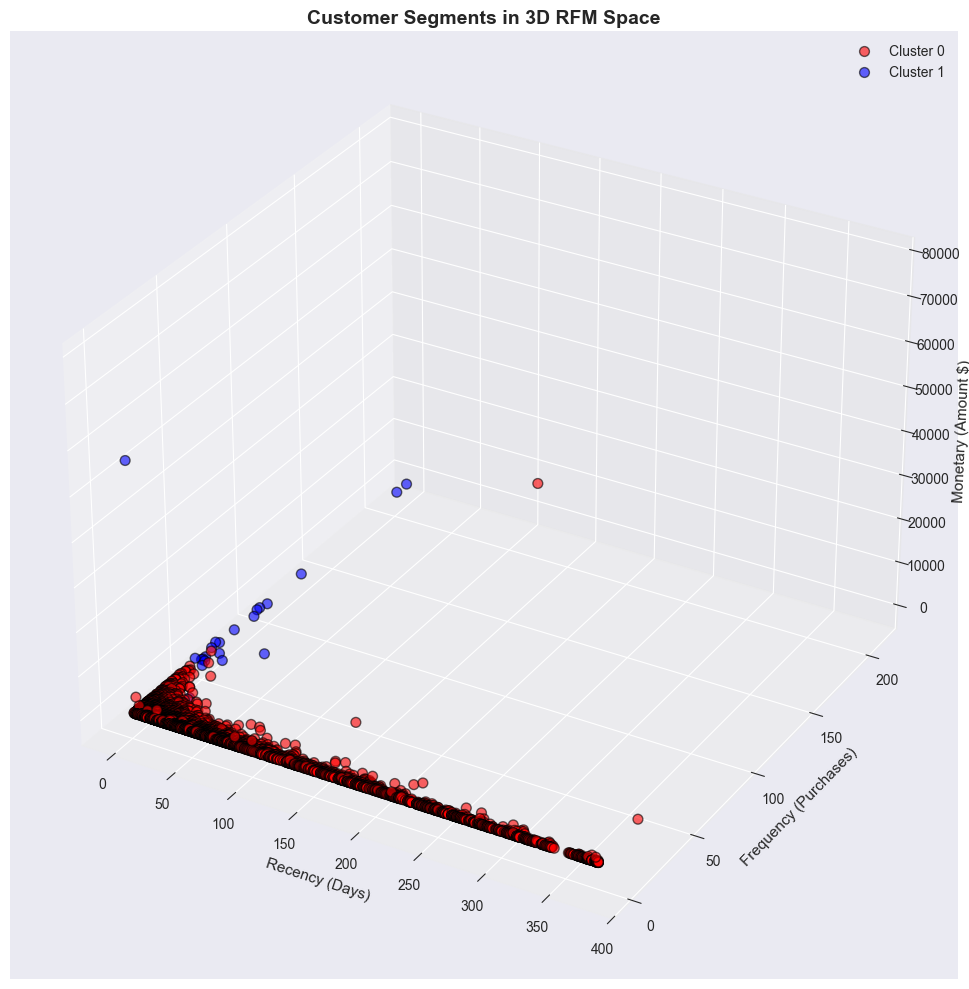

✓ 3D visualization shows customer segments in RFM space


In [92]:
# 3D Scatter plot of clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster with different colors
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], 
              cluster_data['Frequency'], 
              cluster_data['Monetary'],
              c=colors[cluster], 
              label=f'Cluster {cluster}',
              s=50,
              alpha=0.6,
              edgecolors='black')

ax.set_xlabel('Recency (Days)', fontsize=11)
ax.set_ylabel('Frequency (Purchases)', fontsize=11)
ax.set_zlabel('Monetary (Amount $)', fontsize=11)
ax.set_title('Customer Segments in 3D RFM Space', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print("✓ 3D visualization shows customer segments in RFM space")

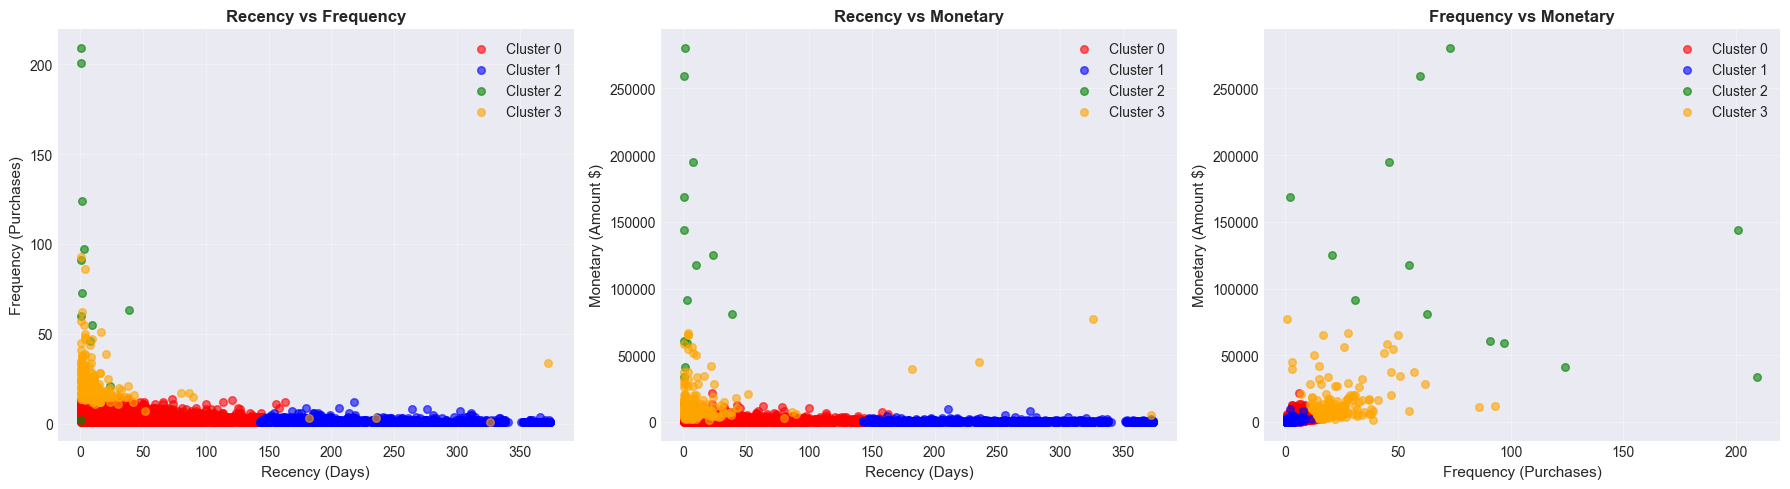

✓ 2D projections help understand cluster separation in different dimensions


In [50]:
# 2D Scatter plots for all RFM combinations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency vs Frequency
for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[0].scatter(cluster_data['Recency'], cluster_data['Frequency'], 
                   c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6, s=30)
axes[0].set_xlabel('Recency (Days)', fontsize=11)
axes[0].set_ylabel('Frequency (Purchases)', fontsize=11)
axes[0].set_title('Recency vs Frequency', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Recency vs Monetary
for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[1].scatter(cluster_data['Recency'], cluster_data['Monetary'], 
                   c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6, s=30)
axes[1].set_xlabel('Recency (Days)', fontsize=11)
axes[1].set_ylabel('Monetary (Amount $)', fontsize=11)
axes[1].set_title('Recency vs Monetary', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Frequency vs Monetary
for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[2].scatter(cluster_data['Frequency'], cluster_data['Monetary'], 
                   c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6, s=30)
axes[2].set_xlabel('Frequency (Purchases)', fontsize=11)
axes[2].set_ylabel('Monetary (Amount $)', fontsize=11)
axes[2].set_title('Frequency vs Monetary', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ 2D projections help understand cluster separation in different dimensions")

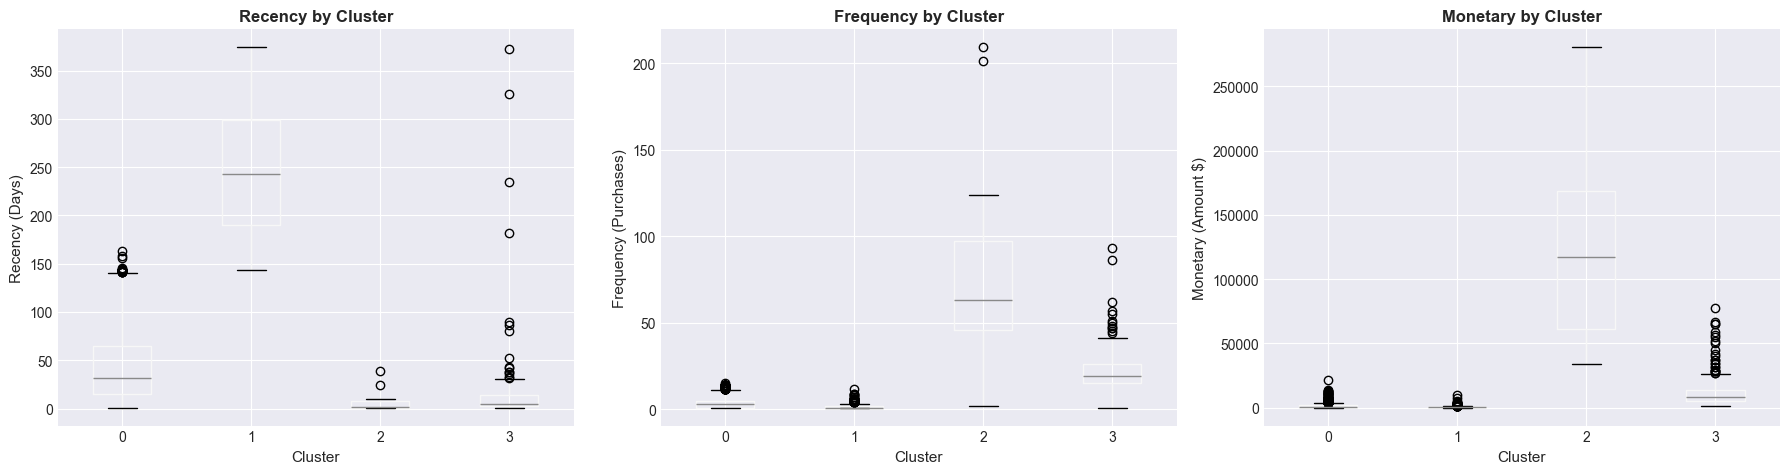

✓ Box plots reveal the distribution of RFM values within each cluster


In [51]:
# Box plots for RFM by cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
rfm.boxplot(column='Recency', by='Cluster', ax=axes[0])
axes[0].set_title('Recency by Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Recency (Days)', fontsize=11)

# Frequency
rfm.boxplot(column='Frequency', by='Cluster', ax=axes[1])
axes[1].set_title('Frequency by Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Frequency (Purchases)', fontsize=11)

# Monetary
rfm.boxplot(column='Monetary', by='Cluster', ax=axes[2])
axes[2].set_title('Monetary by Cluster', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster', fontsize=11)
axes[2].set_ylabel('Monetary (Amount $)', fontsize=11)

plt.suptitle('')
plt.tight_layout()
plt.show()

print("✓ Box plots reveal the distribution of RFM values within each cluster")

### 8.5 Cluster Naming and Business Interpretation

Based on the RFM analysis, we can name and interpret each cluster for business use.

In [52]:
# Create cluster interpretation
# Note: Adjust these labels based on your actual cluster characteristics
cluster_labels = {}

# Analyze each cluster to assign meaningful names
for cluster_id in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster_id]
    avg_recency = cluster_data['Recency'].mean()
    avg_frequency = cluster_data['Frequency'].mean()
    avg_monetary = cluster_data['Monetary'].mean()
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}:")
    print(f"{'='*70}")
    print(f"  Size: {len(cluster_data)} customers ({len(cluster_data)/len(rfm)*100:.1f}%)")
    print(f"  Avg Recency: {avg_recency:.1f} days")
    print(f"  Avg Frequency: {avg_frequency:.1f} purchases")
    print(f"  Avg Monetary: ${avg_monetary:,.2f}")
    
    # Assign label based on RFM characteristics
    if avg_recency < rfm['Recency'].median() and avg_frequency > rfm['Frequency'].median() and avg_monetary > rfm['Monetary'].median():
        label = "Champions"
        description = "Best customers - Recent, frequent, high spenders"
    elif avg_frequency > rfm['Frequency'].quantile(0.75) and avg_monetary > rfm['Monetary'].quantile(0.75):
        label = "Loyal Customers"
        description = "Frequent and high-value customers"
    elif avg_recency < rfm['Recency'].median() and avg_monetary > rfm['Monetary'].median():
        label = "Big Spenders"
        description = "Recent high-value customers"
    elif avg_recency > rfm['Recency'].quantile(0.75):
        label = "At Risk"
        description = "Haven't purchased recently - need attention"
    elif avg_frequency < rfm['Frequency'].median() and avg_monetary < rfm['Monetary'].median():
        label = "Low Value"
        description = "Infrequent and low-spending customers"
    else:
        label = f"Segment {cluster_id}"
        description = "Regular customers"
    
    cluster_labels[cluster_id] = label
    print(f"\n  → Segment Name: {label}")
    print(f"  → Description: {description}")

# Add labels to dataframe
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print(f"\n{'='*70}")
print("\n✓ Clusters labeled and interpreted for business use")


CLUSTER 0:
  Size: 3054 customers (70.4%)
  Avg Recency: 43.7 days
  Avg Frequency: 3.7 purchases
  Avg Monetary: $1,359.05

  → Segment Name: Champions
  → Description: Best customers - Recent, frequent, high spenders

CLUSTER 1:
  Size: 1067 customers (24.6%)
  Avg Recency: 248.1 days
  Avg Frequency: 1.6 purchases
  Avg Monetary: $480.62

  → Segment Name: At Risk
  → Description: Haven't purchased recently - need attention

CLUSTER 2:
  Size: 13 customers (0.3%)
  Avg Recency: 7.4 days
  Avg Frequency: 82.5 purchases
  Avg Monetary: $127,338.31

  → Segment Name: Champions
  → Description: Best customers - Recent, frequent, high spenders

CLUSTER 3:
  Size: 204 customers (4.7%)
  Avg Recency: 15.5 days
  Avg Frequency: 22.3 purchases
  Avg Monetary: $12,709.09

  → Segment Name: Champions
  → Description: Best customers - Recent, frequent, high spenders


✓ Clusters labeled and interpreted for business use


### 8.6 Segment Distribution Visualization

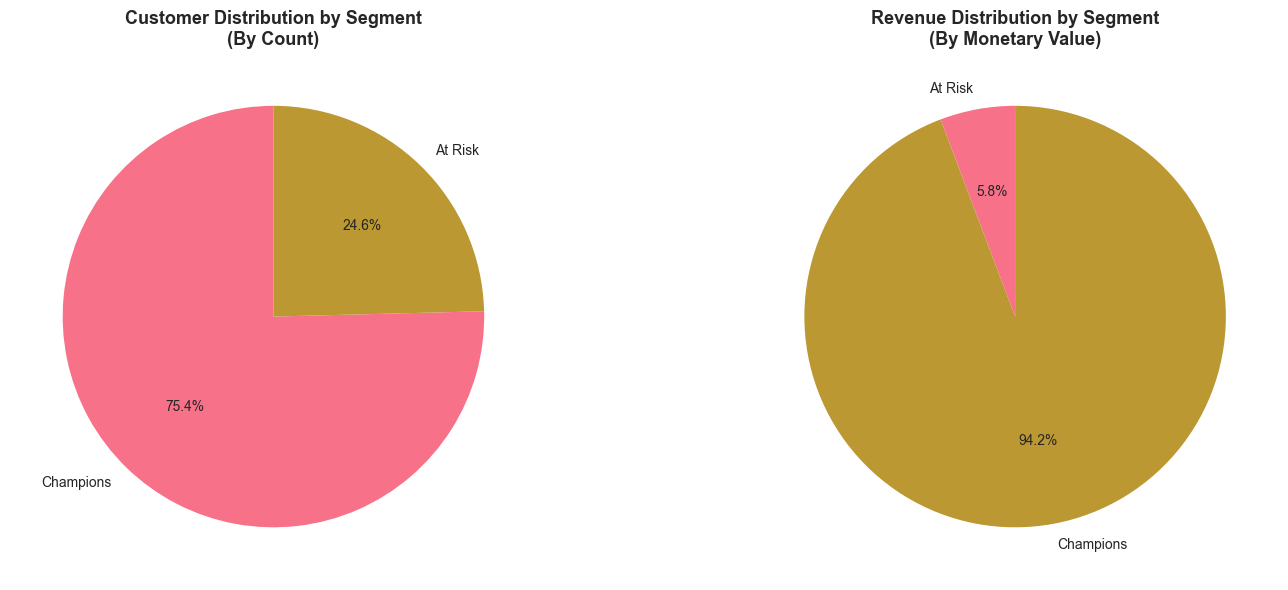

✓ Pie charts show customer and revenue distribution across segments


In [53]:
# Pie chart of customer segments
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# By count
segment_counts = rfm['Segment'].value_counts()
ax1.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Customer Distribution by Segment\n(By Count)', fontsize=13, fontweight='bold')

# By monetary value
segment_monetary = rfm.groupby('Segment')['Monetary'].sum()
ax2.pie(segment_monetary.values, labels=segment_monetary.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Revenue Distribution by Segment\n(By Monetary Value)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Pie charts show customer and revenue distribution across segments")

### 8.7 Heatmap of Cluster Characteristics

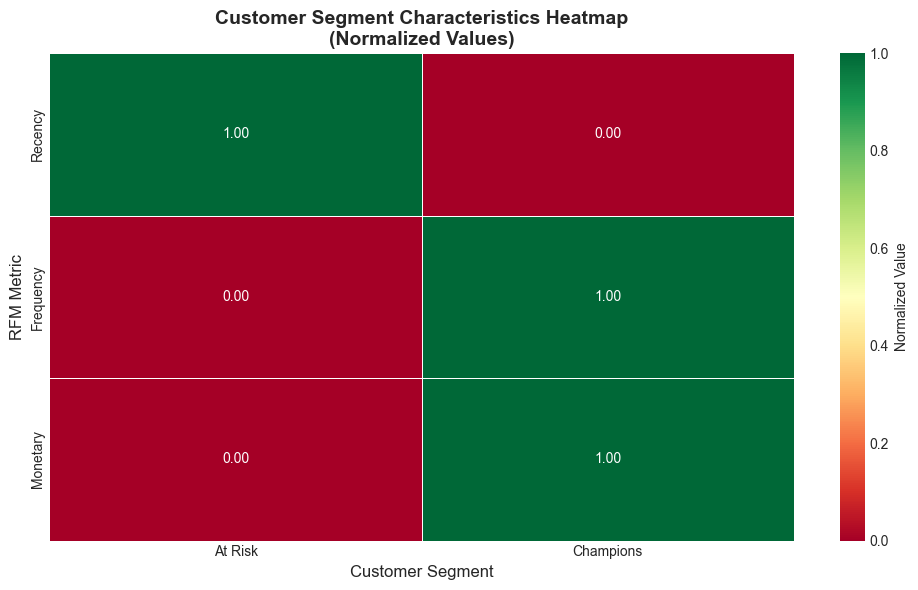


INTERPRETATION:
- Green = High values (good for Frequency & Monetary, bad for Recency)
- Red = Low values (bad for Frequency & Monetary, good for Recency)
- Recency: Lower is better (recent customers)
- Frequency & Monetary: Higher is better


In [54]:
# Create heatmap of normalized RFM values by segment
segment_avg = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

# Normalize for better visualization
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
segment_avg_normalized = pd.DataFrame(
    scaler_viz.fit_transform(segment_avg),
    columns=segment_avg.columns,
    index=segment_avg.index
)

plt.figure(figsize=(10, 6))
sns.heatmap(segment_avg_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Normalized Value'}, linewidths=0.5)
plt.title('Customer Segment Characteristics Heatmap\n(Normalized Values)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('RFM Metric', fontsize=12)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("- Green = High values (good for Frequency & Monetary, bad for Recency)")
print("- Red = Low values (bad for Frequency & Monetary, good for Recency)")
print("- Recency: Lower is better (recent customers)")
print("- Frequency & Monetary: Higher is better")

## 9. Final Results and Business Recommendations

### 9.1 Summary Statistics by Segment

In [55]:
# Final summary table
final_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'sum']
}).round(2)

final_summary.columns = ['Customer_Count', 'Avg_Recency', 'Med_Recency', 
                        'Avg_Frequency', 'Med_Frequency', 
                        'Avg_Monetary', 'Med_Monetary', 'Total_Revenue']

# Add percentage
final_summary['Pct_Customers'] = (final_summary['Customer_Count'] / final_summary['Customer_Count'].sum() * 100).round(1)
final_summary['Pct_Revenue'] = (final_summary['Total_Revenue'] / final_summary['Total_Revenue'].sum() * 100).round(1)

print("FINAL CUSTOMER SEGMENT SUMMARY")
print("="*120)
print(final_summary)
print("="*120)

FINAL CUSTOMER SEGMENT SUMMARY
           Customer_Count  Avg_Recency  Med_Recency  Avg_Frequency  \
Segment                                                              
At Risk              1067       248.08       243.00           1.55   
Champions            3271        41.80        30.00           5.16   

           Med_Frequency  Avg_Monetary  Med_Monetary  Total_Revenue  \
Segment                                                               
At Risk             1.00        480.62        310.47      512818.85   
Champions           3.00       2567.59        924.60     8398589.05   

           Pct_Customers  Pct_Revenue  
Segment                                
At Risk            24.60         5.80  
Champions          75.40        94.20  


### 9.2 Save Results

In [56]:
# Save the segmented customers to CSV
rfm.to_csv('customer_segments.csv', index=False)
print("✓ Customer segments saved to 'customer_segments.csv'")

# Display sample of final results
print("\nSample of segmented customers:")
print(rfm.head(10))

✓ Customer segments saved to 'customer_segments.csv'

Sample of segmented customers:
   CustomerID  Recency  Frequency  Monetary  Cluster    Segment
0    12346.00      326          1  77183.60        3  Champions
1    12347.00        2          7   4310.00        0  Champions
2    12348.00       75          4   1797.24        0  Champions
3    12349.00       19          1   1757.55        0  Champions
4    12350.00      310          1    334.40        1    At Risk
5    12352.00       36          8   2506.04        0  Champions
6    12353.00      204          1     89.00        1    At Risk
7    12354.00      232          1   1079.40        1    At Risk
8    12355.00      214          1    459.40        1    At Risk
9    12356.00       23          3   2811.43        0  Champions


### 9.3 Business Recommendations by Segment

In [57]:
print("BUSINESS RECOMMENDATIONS")
print("="*100)

recommendations = {
    "Champions": {
        "strategy": "Reward and Retain",
        "actions": [
            "VIP treatment with exclusive offers",
            "Early access to new products",
            "Personalized thank-you messages",
            "Request referrals and testimonials",
            "Build loyalty programs"
        ]
    },
    "Loyal Customers": {
        "strategy": "Upsell and Cross-sell",
        "actions": [
            "Recommend related products",
            "Offer bundle deals",
            "Invite to loyalty programs",
            "Send personalized product suggestions",
            "Reward for continued loyalty"
        ]
    },
    "Big Spenders": {
        "strategy": "Increase Frequency",
        "actions": [
            "Encourage repeat purchases",
            "Subscription or membership offers",
            "Limited-time promotions",
            "Personalized recommendations",
            "Exclusive product launches"
        ]
    },
    "At Risk": {
        "strategy": "Re-engage and Win Back",
        "actions": [
            "Send win-back campaigns",
            "Special discount offers",
            "Survey to understand issues",
            "Personalized re-engagement emails",
            "Highlight new products/features"
        ]
    },
    "Low Value": {
        "strategy": "Nurture or Let Go",
        "actions": [
            "Low-cost marketing campaigns",
            "Educational content about products",
            "Entry-level product promotions",
            "Assess acquisition cost vs. value",
            "Focus resources on higher segments if ROI is low"
        ]
    }
}

for segment in rfm['Segment'].unique():
    if segment in recommendations:
        print(f"\n{segment.upper()}")
        print("-"*100)
        print(f"Strategy: {recommendations[segment]['strategy']}")
        print(f"\nRecommended Actions:")
        for i, action in enumerate(recommendations[segment]['actions'], 1):
            print(f"  {i}. {action}")

print("\n" + "="*100)

BUSINESS RECOMMENDATIONS

CHAMPIONS
----------------------------------------------------------------------------------------------------
Strategy: Reward and Retain

Recommended Actions:
  1. VIP treatment with exclusive offers
  2. Early access to new products
  3. Personalized thank-you messages
  4. Request referrals and testimonials
  5. Build loyalty programs

AT RISK
----------------------------------------------------------------------------------------------------
Strategy: Re-engage and Win Back

Recommended Actions:
  1. Send win-back campaigns
  2. Special discount offers
  3. Survey to understand issues
  4. Personalized re-engagement emails
  5. Highlight new products/features



## 10. Key Takeaways and Conclusion

### Summary of Methods Used:

1. **Data Cleaning**: Removed missing values, cancelled orders, and invalid data
2. **RFM Analysis**: Created customer features based on Recency, Frequency, and Monetary value
3. **Feature Scaling**: Applied StandardScaler, MinMaxScaler, and RobustScaler for comparison
4. **Optimal Cluster Selection**:
   - **Elbow Method (WSS)**: Identified the point where adding clusters provides diminishing returns
   - **Silhouette Score**: Measured cluster quality and separation
   - **Visual Analysis**: Used silhouette plots to validate cluster assignments
5. **K-Means Clustering**: Segmented customers into distinct groups
6. **Business Interpretation**: Named segments and provided actionable recommendations

### Impact of Different Metrics:

**WSS (Within-Cluster Sum of Squares):**
- Measures cluster compactness
- Lower is better, but need to balance with number of clusters
- Helps identify the elbow point

**Silhouette Score:**
- Measures cluster separation and cohesion
- Range: -1 to +1 (higher is better)
- Score > 0.5 indicates good clustering
- Helps validate optimal k selection

**Feature Scaling:**
- StandardScaler: Best for normally distributed data
- MinMaxScaler: Best for bounded values [0,1]
- RobustScaler: Best when data has outliers
- Critical for K-Means as it uses Euclidean distance

### Business Value:

✓ Identified distinct customer segments with unique characteristics  
✓ Enabled targeted marketing strategies for each segment  
✓ Optimized resource allocation based on customer value  
✓ Improved customer retention and acquisition strategies  
✓ Data-driven approach to customer relationship management  

### Next Steps:

1. Monitor segment migration over time
2. A/B test marketing strategies for each segment
3. Build predictive models for segment classification
4. Integrate segmentation into CRM systems
5. Regular re-segmentation (quarterly or bi-annually)